# Intelligent Login Risk Analyzer  
## Notebook 05: Model Evaluation

This notebook evaluates the anomaly detection results generated by the Isolation Forest model.

The goal is not traditional classification accuracy, because this is an unsupervised anomaly detection task. Instead, we inspect anomaly distribution, suspicious patterns, and alignment with risk-related features.

## Step 1: Import Required Libraries

We import the libraries needed for loading prediction outputs and performing evaluation analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load Prediction Results

We load the model prediction output generated in Notebook 04.

In [2]:
df_eval = pd.read_csv('../outputs/model_predictions.csv')
df_eval.head()

,is_failed,is_night_login,is_high_risk_location,is_suspicious_device,user_user10,user_user11,user_user12,user_user13,user_user14,user_user15,...,location_Rajshahi,location_Russia,location_Sylhet,location_UK,location_USA,device_or_browser_Edge,device_or_browser_Firefox,device_or_browser_Mobile,anomaly_prediction,anomaly_label
0,1,0,0,0,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,1,Normal
1,1,1,0,0,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,1,Normal
2,1,1,0,0,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,1,Normal
3,0,0,0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,1,Normal
4,1,0,0,1,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,1,Normal


## Step 3: Review Prediction Distribution

This step shows how many records were classified as normal and how many were flagged as anomalies.

In [3]:
df_eval['anomaly_label'].value_counts()

anomaly_label
Normal     270
Anomaly     30
Name: count, dtype: int64

### Visualization: Prediction Distribution

We visualize the model output to understand the proportion of anomalous records.

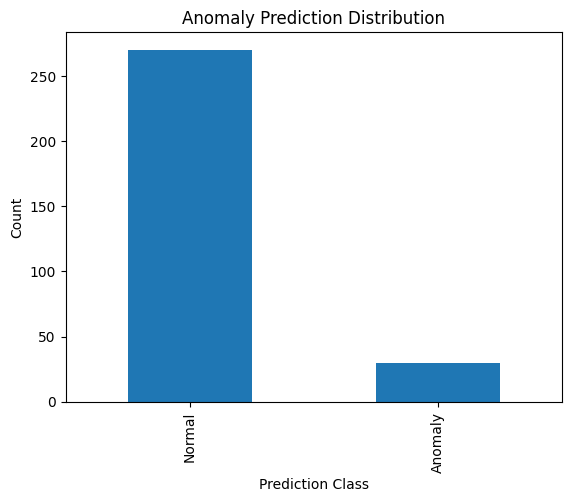

In [4]:
df_eval['anomaly_label'].value_counts().plot(kind='bar')
plt.title('Anomaly Prediction Distribution')
plt.xlabel('Prediction Class')
plt.ylabel('Count')
plt.show()

## Step 4: Compare Risk Features in Anomalies

We examine whether anomalous records are associated with meaningful risk-related features such as:
- failed logins
- night-time activity
- high-risk locations
- suspicious device usage

anomalies = df_eval[df_eval['anomaly_label'] == 'Anomaly']

anomalies[['is_failed', 'is_night_login', 'is_high_risk_location', 'is_suspicious_device']].sum()

## Step 5: Compare Average Feature Values

We compare average feature values between normal and anomalous records to see whether anomalies carry stronger suspicious signals.

In [7]:
df_eval.groupby('anomaly_label')[['is_failed', 'is_night_login', 'is_high_risk_location', 'is_suspicious_device']].mean()

,is_failed,is_night_login,is_high_risk_location,is_suspicious_device
anomaly_label,,,,
Anomaly,0.533333,0.466667,0.466667,0.300000
Normal,0.544444,0.274074,0.081481,0.311111


## Step 6: Calculate Anomaly Percentage

This step calculates the percentage of records flagged as anomalies.

In [8]:
anomaly_percentage = (df_eval['anomaly_label'].value_counts(normalize=True) * 100)
print(anomaly_percentage)

anomaly_label
Normal     90.0
Anomaly    10.0
Name: proportion, dtype: float64


## Step 7: Build a Simple Suspicion Reference Score

To interpret the model output, we create a basic reference score using the engineered rule-based features.

This is not a ground-truth label, but it helps us judge whether the model is flagging records that also look suspicious from a security perspective.

In [9]:
df_eval['reference_score'] = (
    df_eval['is_failed'] +
    df_eval['is_night_login'] +
    df_eval['is_high_risk_location'] +
    df_eval['is_suspicious_device']
)

df_eval[['reference_score', 'anomaly_label']].head()

,reference_score,anomaly_label
0,1,Normal
1,2,Normal
2,2,Normal
3,0,Normal
4,2,Normal


## Step 8: Compare Reference Score by Prediction Class

If the model is behaving reasonably, anomalous records should tend to have higher reference scores than normal records.

In [10]:
df_eval.groupby('anomaly_label')['reference_score'].mean()

anomaly_label
Anomaly    1.766667
Normal     1.211111
Name: reference_score, dtype: float64

## Step 9: Inspect Highly Suspicious Anomalies

We review anomaly records with the highest reference scores to understand the strongest suspicious cases flagged by the system.

In [11]:
df_eval[df_eval['anomaly_label'] == 'Anomaly'].sort_values(by='reference_score', ascending=False).head(10)

,is_failed,is_night_login,is_high_risk_location,is_suspicious_device,user_user10,user_user11,user_user12,user_user13,user_user14,user_user15,...,location_Russia,location_Sylhet,location_UK,location_USA,device_or_browser_Edge,device_or_browser_Firefox,device_or_browser_Mobile,anomaly_prediction,anomaly_label,reference_score
147,1,1,1,1,False,False,False,True,False,False,...,True,False,False,False,False,False,True,-1,Anomaly,4
142,1,0,1,1,False,False,False,False,False,False,...,True,False,False,False,False,False,True,-1,Anomaly,3
196,1,0,1,1,False,False,False,False,False,False,...,True,False,False,False,False,False,True,-1,Anomaly,3
244,1,0,1,1,False,False,False,False,False,False,...,True,False,False,False,False,False,True,-1,Anomaly,3
258,1,1,0,1,False,False,False,True,False,False,...,False,False,False,False,False,False,True,-1,Anomaly,3
52,1,0,1,0,False,False,False,False,False,False,...,True,False,False,False,True,False,False,-1,Anomaly,2
114,0,1,0,1,False,False,True,False,False,False,...,False,False,False,False,False,False,True,-1,Anomaly,2
138,0,1,1,0,False,False,False,False,False,False,...,True,False,False,False,False,False,False,-1,Anomaly,2
154,1,1,0,0,False,False,False,False,False,False,...,False,False,False,False,False,True,False,-1,Anomaly,2
105,0,1,1,0,False,False,False,False,False,False,...,True,False,False,False,True,False,False,-1,Anomaly,2


## Step 10: Evaluation Interpretation

In unsupervised anomaly detection, evaluation focuses on whether the flagged records are meaningfully suspicious rather than whether they match perfect labels.

A useful model should:
- flag a relatively small portion of records
- assign anomalies to records with stronger suspicious indicators
- support analysts by prioritizing cases for review

## Step 11: Save Evaluation Dataset

We save the evaluated dataset for use in the detection pipeline notebook.

In [12]:
df_eval.to_csv('../outputs/evaluated_predictions.csv', index=False)

## Summary

In this notebook, we:
- reviewed anomaly prediction distribution
- examined whether anomalies align with suspicious login features
- compared normal and anomalous records
- created a reference suspicion score for interpretation
- saved the evaluated output for the next stage

This evaluation shows whether the anomaly detection model is producing meaningful cybersecurity signals.

## Important Note

Because this project uses an unsupervised anomaly detection approach on a synthetic dataset, the detected anomalies should be interpreted as suspicious patterns rather than confirmed attacks.

In a real-world security environment, these outputs would support analyst review, alert prioritization, and further investigation.